# FS→DSA Final Analysis — France

This notebook guides through an analysis of France's MTP and the implications of policy-dependent potential output within the DSA. It can be run top-to-bottom without prior knowledge of the codebase. 

What the notebook will do:
- Load the FS and DSA models. For this excercise, only the supply block of the FS model is relevant: with no structural changes in taxation, the FS supply block is basically equivalent to the key trend equations in the PREM model.
- Enter MTP-informed baseline paths (SPB, potential growth & inflation)
    - Reasoning: We are asusming that the policies named in the MTP are consistent with the specified potential output and inflation paths. I.e.: The specified policy mix will lead to the specified macroeconomic conditions.
    - As GDP is endogenously calculated in the DSA based on PO and output gap, we do not use the (already endogenous) GDP path from the MTP as the baseline.
- Evaluate whether the SPB path from the MTP is still the binding SPB path given newly available data.
- Find the actual binding SPB path to form our baseline.
- Calibrate FS baseline to DSA.
- Run a policy scenario in FS and port it back to DSA.
- Compute the binding SPB path under different potential output assumptuons and compare baseline and scenario SPB target (fiscal space assessment)


## 1) Setup and imports

In [1]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Add the model directories to Python path
sys.path.append('model/fs')
sys.path.append('model/dsa/code/classes')

# Direct imports (no package structure)
from data_functions import load_and_process_data
from model_equations import build_model
from scenario_functions import initialize_model, run_scenario_analysis
from integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb
from StochasticDsaModelClass import StochasticDsaModel as DSA

# Analysis toggles
START, END = 2025, 2041

## 2) Import data
Load FS data and prepare the DSA model. 

In [2]:

FR = load_and_process_data(data_folder='data', sheet_name='France')
FS_model = build_model(include_fiscal=True)
data_FR = FS_model.insertModelVar(FR)
print('FR data shape:', FR.shape)

# set output gap mechanism in private investment = 0 as we dont assume this effect in PREM yet (all other variables affecting private investment dont change, so no need to adjust them)
data_FR.loc[:, 'LAMBDA_IQ_M_4'] = 0

dsa_fr = DSA(country='FRA', start_year=2024, end_year=2041, adjustment_period=7, adjustment_start_year=2025, fiscal_multiplier_type='ec')
dsa_fr.project()  # seed baseline arrays
df_fr = dsa_fr.df(all=True)

FR data shape: (84, 223)


## 3) Specify MTP paths (SPB, potential growth, inflation) and policy measures
The dictionaries below can be edited to specify different assumptions.
- SPB: level path (% of GDP)
- rg_pot: potential GDP growth (percent)
- pi: GDP deflator inflation (percent); available only up to 2029/2031 — we auto-align later years


In [3]:
years_full = list(range(dsa_fr.start_year, dsa_fr.end_year + 1))

# --- SPB level path from MTP, constant after ---
mtfp_spb_points = {
    2024: -3.6, 2025: -2.3, 2026: -1.7, 2027: -1.0, 2028: -0.3,
    2029: 0.3, 2030: 1.1, 2031: 1.8
}
mtfp_spb = pd.Series(mtfp_spb_points).reindex(years_full).interpolate().ffill().bfill()

# --- Potential GDP growth anchors constant after ---
mtfp_rg_pot_points = {
    2025: 1.2, 2026: 1.2, 2027: 1.2, 2028: 1.2, 2029: 1.0, 2030: 1.0, 2031: 1.0
}
mtfp_rg_pot = pd.Series(mtfp_rg_pot_points).reindex(years_full).interpolate().ffill().bfill()

# --- Inflation ---
mtfp_pi_points = {
    2025: 1.7, 2026: 1.6, 2027: 1.6, 2028: 1.6, 2029: 1.6, 2030: 1.6, 2031: 1.6,
    2032: 1.8, 2033: 1.8, 2034: 1.8, 2035: 1.8, 2036: 1.8, 2037: 1.8, 2038: 1.8, 2039: 1.8, 2040: 1.8, 2041: 1.8
}

In [4]:
# Apply your MTP inflation and potential growth assumptions
mtp_anchors = {
    'rg_pot': pd.Series(mtfp_rg_pot),  # Potential growth
    'pi': mtfp_pi_points,              # Inflation path
}

# Convert your SPB level path to steps directly
a0 = dsa_fr.adjustment_start  # This is 1 (2025)
a1 = dsa_fr.adjustment_end    # This is 7 (2031)
years = np.arange(dsa_fr.start_year, dsa_fr.end_year + 1)  # [2024, 2025, ..., 2045]

# Get your SPB levels aligned to model years
spb_full = mtfp_spb.reindex(years).to_numpy()

# Calculate steps for adjustment period only
spb_steps = np.zeros(dsa_fr.adjustment_period)  # Array of 7 zeros
for t in range(a0, a1 + 1):  # t goes from 1 to 7
    spb_steps[t - a0] = spb_full[t] - spb_full[t - 1]

print(f"SPB steps: {spb_steps}")
print(f"SPB levels: {spb_full[1:8]}")  # Show the levels for 2025-2031

SPB steps: [1.3 0.6 0.7 0.7 0.6 0.8 0.7]
SPB levels: [-2.3 -1.7 -1.  -0.3  0.3  1.1  1.8]


## 4) Initialise baseline

Project the debt ratio with the planned policies, assuming that they will lead to the specified potential output, SPB, and inflation changes/levels specified in the plan.

In [5]:
dsa_fr.spb_bca[0] = -3.6
dsa_fr.spb[0] = -3.6
apply_mtp_anchors_to_dsa(dsa_fr, anchors=mtp_anchors, inplace=True)
dsa_fr.growth_driven_preclosure = False
dsa_fr.project(spb_steps=spb_steps)
df_fr = dsa_fr.df(all=True)


In [6]:
dsa_bl_opt = copy.deepcopy(dsa_fr)
dsa_bl_opt.find_spb_binding(print_results=False)
df_bl_opt = dsa_bl_opt.df(all=True)
print(f"SPB: {dsa_fr.spb_bca[7]:.2f}% vs Binding: {dsa_bl_opt.binding_spb_target:.2f}%")

SPB: 1.80% vs Binding: 2.23%


In [7]:
# Extract rg_pot and pi series from dsa_bl_opt
rg = pd.Series(dsa_bl_opt.rg, index=years, name='rg')
rg_pot = pd.Series(dsa_bl_opt.rg_pot, index=years, name='rg_pot')
pi = pd.Series(dsa_bl_opt.pi, index=years, name='pi')

bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}


In [8]:

baseline_FR = initialize_model(
    data=data_FR, 
    model_class=FS_model, 
    start=START, 
    end=END,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  # This should use your DSA model
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(dsa_bl_opt),  # Use the binding DSA model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

## 5) Scenario analysis
Estimate the impact of the policy measures in the FS model, then port the scenario potential into DSA for comparison.

In [9]:
# Calculate initial LF
LF = data_FR.loc[2025:2027, 'WP'] * data_FR.loc[2025:2027, 'LP'] / 100

# Decrease LF for 2026 and 2027 by 42000
LF_new = LF.copy()
LF_new.loc[2026:2027] -= 42000

# Calculate new LP and the difference
LP_new = LF_new / data_FR.loc[2025:2027, 'WP'] * 100
LP_diff = LP_new - data_FR.loc[2025:2027, 'LP']

print("\nLP_diff (2025-2027):")
print(LP_diff)



LP_diff (2025-2027):
YEAR
2025    0.000000
2026   -0.083560
2027   -0.083464
dtype: float64


In [10]:
#participation decreases by 42000  over two years.
measures = [
    { 'var': 'EPS_LP', 'values': LP_diff, 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
]


In [11]:
scenario_FR = run_scenario_analysis(
    baseline_result=baseline_FR, model_class=FS_model,
    scenario_shocks=measures, scenario_name='FR_policy'
)


,Period 1,Period 2,Period 3
EPS_LP,0.0,-0.08356,-0.083464


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

Calculate a smoothed potential output growth path for better comparison to smoothed PO growth path in MTP.

In [12]:
# Calculate smoothed growth rates for France (FR) in two periods: 2024-2028 and 2028-2041

# --- 2024 to 2028 ---
start_2024 = scenario_FR.loc[2024, 'Y_STAR']
end_2028 = scenario_FR.loc[2028, 'Y_STAR']
growth_factor_24_28 = end_2028 / start_2024
years_24_28 = 2028 - 2024  # 4 years
const_growth_rate_24_28 = (growth_factor_24_28 ** (1/years_24_28)) - 1

# Create smoothed Y_STAR series for 2024-2028
scenario_FR['Y_STAR_smooth_24_28'] = scenario_FR['Y_STAR'].copy()
scenario_FR.loc[2024, 'Y_STAR_smooth_24_28'] = start_2024
for year in range(2025, 2029):
    scenario_FR.loc[year, 'Y_STAR_smooth_24_28'] = start_2024 * ((1 + const_growth_rate_24_28) ** (year - 2024))
scenario_FR['Y_STAR_growth_smooth_24_28'] = scenario_FR['Y_STAR_smooth_24_28'].pct_change() * 100

# --- 2028 to 2041 ---
start_2028 = scenario_FR.loc[2028, 'Y_STAR']
end_2041 = scenario_FR.loc[2041, 'Y_STAR']
growth_factor_28_41 = end_2041 / start_2028
years_28_41 = 2041 - 2028  # 13 years
const_growth_rate_28_41 = (growth_factor_28_41 ** (1/years_28_41)) - 1

# Create smoothed Y_STAR series for 2028-2041
scenario_FR['Y_STAR_smooth_28_41'] = scenario_FR['Y_STAR'].copy()
scenario_FR.loc[2028, 'Y_STAR_smooth_28_41'] = start_2028
for year in range(2029, 2042):
    scenario_FR.loc[year, 'Y_STAR_smooth_28_41'] = start_2028 * ((1 + const_growth_rate_28_41) ** (year - 2028))
scenario_FR['Y_STAR_growth_smooth_28_41'] = scenario_FR['Y_STAR_smooth_28_41'].pct_change() * 100

print(f"2024-2028: Total growth factor: {growth_factor_24_28:.4f}")
print(f"2024-2028: Constant annual growth rate: {const_growth_rate_24_28*100:.2f}%")
print(f"2024-2028: Growth from 2024 to 2028: {(growth_factor_24_28-1)*100:.2f}%")
print("-" * 40)
print(f"2028-2041: Total growth factor: {growth_factor_28_41:.4f}")
print(f"2028-2041: Constant annual growth rate: {const_growth_rate_28_41*100:.2f}%")
print(f"2028-2041: Growth from 2028 to 2041: {(growth_factor_28_41-1)*100:.2f}%")

2024-2028: Total growth factor: 1.0471
2024-2028: Constant annual growth rate: 1.16%
2024-2028: Growth from 2024 to 2028: 4.71%
----------------------------------------
2028-2041: Total growth factor: 1.1379
2028-2041: Constant annual growth rate: 1.00%
2028-2041: Growth from 2028 to 2041: 13.79%


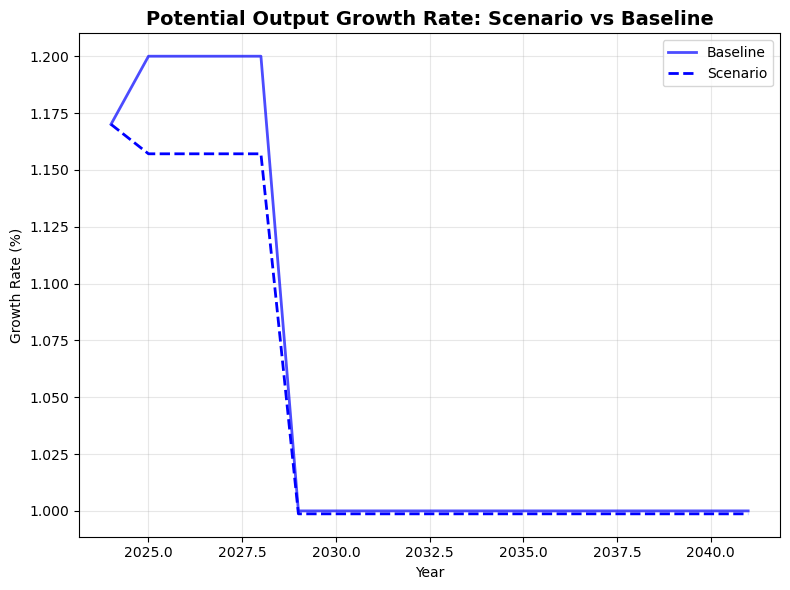

In [13]:
# Create single plot for Scenario 4 (France) using smoothed scenario growth rates
plt.figure(figsize=(8, 6))
plt.title('Potential Output Growth Rate: Scenario vs Baseline', fontsize=14, fontweight='bold')

# Define years for x-axis (2024 to 2041)
years_plot = range(2024, 2042)

# Plot baseline for France (original G_Y_STAR)
plt.plot(
    years_plot,
    baseline_FR.loc[years_plot, 'G_Y_STAR'],
    color='blue',
    linestyle='-',
    linewidth=2,
    label='Baseline',
    alpha=0.7
)

# Plot scenario for France using smoothed growth rates
# Use 'Y_STAR_growth_smooth_24_28' for 2024-2028, 'Y_STAR_growth_smooth_28_41' for 2028-2041
scenario_growth = []
for year in years_plot:
    if year <= 2028:
        scenario_growth.append(scenario_FR.loc[year, 'Y_STAR_growth_smooth_24_28'])
    else:
        scenario_growth.append(scenario_FR.loc[year, 'Y_STAR_growth_smooth_28_41'])

plt.plot(
    years_plot,
    scenario_growth,
    color='blue',
    linestyle='--',
    linewidth=2,
    label='Scenario'
)

plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6) Optimal path & fiscal space
Compare binding SPB paths for baseline and scenario and convert differences into EUR amounts.

In [14]:
# Create DSA model
dsa_scenario = copy.deepcopy(dsa_fr)

# Define growth periods with two different levels
france_growth_periods = [
    {'start_year': 2025, 'end_year': 2028, 'growth_rate': const_growth_rate_24_28*100},
    {'start_year': 2029, 'end_year': 2041, 'growth_rate': const_growth_rate_28_41*100}
]

# Apply potential output from FS scenarios to DSA models with two-level smoothed growth
apply_fs_potential_to_dsa(dsa_scenario, fs_df=scenario_FR, inplace=True, 
                         growth_periods=france_growth_periods)

# Now run DSA projections
dsa_scenario.project(spb_steps=spb_steps)


In [15]:
#find optimal/binding SPB path
dsa_sce_opt = copy.deepcopy(dsa_scenario)
dsa_sce_opt.find_spb_binding(
        print_results=True
    )
df_sce_opt = dsa_sce_opt.df(all=True)
    
sce_opt_tgt = float(dsa_sce_opt.binding_spb_target)
sce_opt_steps = dsa_sce_opt.binding_parameter_dict['spb_steps'].copy()

print(f"Baseline Binding: {dsa_bl_opt.spb_bca[7]:.4f}% vs Scenario Binding: {dsa_sce_opt.binding_spb_target:.4f}%")


                  Model Params                             SPB Targets       
================================================     ========================
country                                      FRA     main_adjustment    1.311
adjustment period                              7     lower_spb          1.788
adjustment start                            2025     financial_stress   1.455
shock frequency                        quarterly     adverse_r_g        2.232
stochastic period                      2032-2037     deficit_reduction  1.842
estimation                                normal     stochastic         1.361
bond level data                            False     edp                2.232
safeguards         EDP, debt, deficit_resilience     binding            2.232
================================================     ========================

                                Binding Params                               
spb_steps                     0.833, 0.833, 0.833, 0.833, 0.833

In [18]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario

years = range(2024, 2042)  # 2024-2041

# Helper function to get EUR values
def get_eur_values(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values
def get_pct_values(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary including debt ratio and potential output growth
results = {
    'Year': years,
    'SPB_Baseline_%': [get_pct_values(dsa_bl_opt, y, 'spb_bca') for y in years],
    'SPB_Scenario_%': [get_pct_values(dsa_sce_opt, y, 'spb_bca') for y in years],
    'SPB_Baseline_EUR': [get_eur_values(dsa_bl_opt, y, 'spb_bca') for y in years],
    'SPB_Scenario_EUR': [get_eur_values(dsa_sce_opt, y, 'spb_bca') for y in years],
    'Debt_Baseline_%': [get_pct_values(dsa_bl_opt, y, 'd') for y in years],
    'Debt_Scenario_%': [get_pct_values(dsa_sce_opt, y, 'd') for y in years],
    'PotOut_Growth_Baseline_%': [get_pct_values(dsa_bl_opt, y, 'rg_pot') for y in years],
    'PotOut_Growth_Scenario_%': [get_pct_values(dsa_sce_opt, y, 'rg_pot') for y in years],
}

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Calculate differences
comparison_df['SPB_Diff_%'] = comparison_df['SPB_Scenario_%'] - comparison_df['SPB_Baseline_%']
comparison_df['SPB_Diff_EUR'] = comparison_df['SPB_Scenario_EUR'] - comparison_df['SPB_Baseline_EUR']
comparison_df['Debt_Diff_%'] = comparison_df['Debt_Scenario_%'] - comparison_df['Debt_Baseline_%']
comparison_df['PotOut_Growth_Diff_%'] = comparison_df['PotOut_Growth_Scenario_%'] - comparison_df['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison:")
# Format EUR columns to show in billions (no scientific notation)
eur_cols = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display = comparison_df.copy()
for col in eur_cols:
    comparison_df_display[col] = comparison_df_display[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display.round(3))

SPB, Debt Ratio, and Potential Output Growth Comparison:


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-3.600,-3.600,"-105,170,832,000","-105,170,832,000",112.976,112.976,1.2,1.170,0.000,0,0.000,-0.030
1,2025,-2.768,-2.767,"-82,755,879,522","-82,699,823,279",116.103,116.151,1.2,1.157,0.001,"56,056,242",0.048,-0.043
2,2026,-1.935,-1.934,"-59,278,648,355","-59,185,821,146",118.793,118.890,1.2,1.157,0.001,"92,827,209",0.097,-0.043
3,2027,-1.103,-1.100,"-34,618,241,575","-34,509,229,557",120.917,121.064,1.2,1.157,0.002,"109,012,018",0.147,-0.043
4,2028,-0.270,-0.267,"-8,699,989,666","-8,596,796,718",122.352,122.548,1.2,1.157,0.003,"103,192,948",0.197,-0.043
5,2029,0.562,0.566,"18,566,672,338","18,647,839,928",123.333,123.530,1.0,0.999,0.003,"81,167,590",0.197,-0.001
6,2030,1.395,1.399,"47,208,368,551","47,265,622,087",123.616,123.812,1.0,0.999,0.004,"57,253,536",0.196,-0.001
7,2031,2.227,2.232,"77,305,646,517","77,336,977,018",123.193,123.388,1.0,0.999,0.005,"31,330,501",0.195,-0.001
8,2032,2.227,2.232,"79,955,854,343","79,987,632,839",121.473,121.664,1.0,0.999,0.005,"31,778,496",0.191,-0.001
9,2033,2.227,2.232,"82,694,038,510","82,726,252,931",119.548,119.735,1.0,0.999,0.005,"32,214,422",0.187,-0.001


In [17]:

# Save the comparison dataframe for France
#comparison_df_fr.to_excel('France_Results_v2.xlsx', index=False)
#print("DataFrame saved as 'France_Results_v2.xlsx'")